# ASSET-COMMODITY PRICING
## ECON 323

**GROUP 3 & GROUP 4** 

**MEMBERS**
- Yashas Ganesh Prasad
- Taha Memon
- Jasper Yang
- Xuanfu Zhu
- Syed Zaim Naqvi

**TABLE OF CONTENTS**
- Introduction
- Data Ingestion
- Data Cleaning
- Data Modelling & Inference
- Data Visualization
- Conclusion
- Sources

# **1. INTRODUCTION**

Gold has long played a dual role in the global financial system as both a commodity and a monetary asset with huge economic value (World Gold Council, 2025), distinguishing it from traditional financial securities such as equities and fixed-income instruments. **Unlike stocks or bonds, gold does not generate cash flows (Jaffer, 2024), and its valuation is therefore not based on discounted future earnings**. Instead, gold prices are primarily driven by **macroeconomic fundamentals (like inflation, unemployment, and overall GDP-per-capita growth), financial market conditions, and investor sentiment** (J.P. Morgan, 2025; World Gold Council, 2025). This distinctive characteristic has made gold a focal point in financial economics, particularly in **discussions surrounding portfolio diversification, inflation hedging, and safe-haven behaviour**.

A core finding in the literature is that the real interest rates (interest rates after taking into account inflation) are the primary driver of gold prices. Higher real yields increase the opportunity cost of holding gold, placing downward pressure on its price, while lower or negative real rates tend to support higher gold prices. Closely related is inflation expectations, which influence real rates and shape gold's role as a hedge against declining purchasing power, showing the safe-haven behaviour of gold (Bampinas & Panagiotidis, 2015).

The traditional safe-haven hypothesis suggests that **gold should exhibit a negative relationship with risky assets, such as equities**, and a positive relationship with measures of uncertainty, such as market volatility. This has often been supported by empirical evidence, even during economic recessions, such as the Global Financial Crisis in 2008, when gold prices increased despite declines in equity markets (Baur & McDermott, 2010). 

However, the economic environment following the COVID-19 pandemic has raised questions about the stability of the relationship posited by the safe-haven hypothesis (Li, 2020). The unprecedented monetary expansion during the COVID-19 pandemic and the transition to **monetary tightening beginning on March 16, 2022 (li, 2023), combined with elevated inflation and heightened market volatility, have caused gold prices to deviate from their expected role as a traditional safe-haven asset**. In particular, periods of simultaneous declines in both equity markets and gold prices, along with stronger sensitivity to interest rate movements, suggest a potential shift in gold's role within financial markets.

This has led to the emergence of the Broken Safe-Haven hypothesis (Faraj et al., 2025), which argues that gold's ability to hedge against market risk may have weakened in the post-COVID-19 period. 

To examine this hypothesis, this study adopts a multivariate empirical framework incorporating key macroeconomic and financial variables. Given the potential for multicollinearity among these variables, the analysis uses **LASSO regression, OLS analysis and XGBoost Machine Learning** to assess whether gold continues to function as a safe-haven asset in the post-COVID-19 period.

**Research Question**

Using an empirical framework, does the safe-haven hypothesis for gold prices hold in the post-COVID-19 period, or is there evidence of a structural weakening in its safe-haven properties consistent with a "broken safe-haven" dynamic?

# **2. DATA INGESTION**

The dataset used in this study is constructed from a combination of sources to ensure both data availability and reliability across the key variables. The primary gold price data is obtained from a dataset hosted on Kaggle, which provides a comprehensive dataset on historical gold price series in a structured and readable format. This dataset serves as the dependent variable in the analysis.

The explanatory variables, covering macroeconomic and financial indicators, are sourced from the Federal Reserve Economic Data (FRED), and Yahoo Finance. These platforms are widely used in empirical finance research due to their high-frequency, reliable, and continuously updated data.

A key advantage of using FRED and Yahoo Finance is the ability to directly import data (via APIs). This eliminates the need for manual downloading and the updating of datasets, ensuring reproducibility, efficiency, and consistency in the data collection process.

By integrating data from these sources, the final dataset captures a comprehensive set of variables necessary to analyze gold price dynamics within a multivariate empirical framework.


In [4]:
#installing required libraries
!pip install pandas
!pip install fredapi
!pip install yfinance

In [5]:
import pandas as pd

gold_data = pd.read_csv("Gold-Silver-GeopoliticalRisk_HistoricalData.csv") #allows import of locally dowmloaded dataset
gold_data['DATE'] = pd.to_datetime(gold_data['DATE']) #changes the data type of the column "DATE" to date-time
gold_data.set_index('DATE', inplace=True) #sets DATE as the index of the dataframe
gold_data = gold_data[gold_data.index >= '1999-01-01'] #filters the data to only get data after January 1st 1999
gold_data

,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPRD,GPRD_ACT,GPRD_THREAT,EVENT
DATE,,,,,,,,,,,,,,
2025-09-10,3630.90,3633.61,3634.42,3620.90,-0.07,40.92,40.89,40.94,40.72,0.09,NaN,NaN,NaN,NaN
2025-09-09,3633.61,3637.10,3674.75,3625.33,-0.06,40.89,41.34,41.50,40.77,-1.13,NaN,NaN,NaN,NaN
2025-09-08,3635.84,3586.82,3646.60,3579.67,1.24,41.36,41.01,41.68,40.51,1.20,117.26,97.42,146.26,NaN
2025-09-07,3591.19,3592.07,3596.56,3586.95,0.12,40.86,41.00,41.01,40.76,-0.34,83.51,111.00,92.59,NaN
2025-09-05,3586.81,3547.00,3600.33,3540.05,1.15,41.01,40.69,41.44,40.55,0.76,166.42,110.61,224.05,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999-01-08,291.25,291.05,291.25,291.25,-0.10,5.29,5.22,5.29,5.28,0.76,70.81,61.38,92.16,NaN
1999-01-07,291.55,288.25,291.55,291.55,1.32,5.25,5.16,5.25,5.23,1.55,68.03,64.87,59.03,NaN
1999-01-06,287.75,287.00,287.75,287.75,0.28,5.17,5.03,5.17,5.15,2.58,62.19,71.79,43.55,NaN


In [6]:
from fredapi import Fred
fred = Fred(api_key="77607617679b9e388bc1c17f17bf0874") #using FRED-generated API key to import data directly from FRED database

end = '2025-09-10'
start = '1991-01-01'

# this involves forming a dataframe of various variables imported from the FRED database, using date as the index
# using a specific observation_start and observation_end argument ensures that data is within the required dates
df1 = pd.DataFrame({
'interest_rate' : fred.get_series('REAINTRATREARAT10Y', observation_start = start, observation_end = end), 
'inflation_rate' : fred.get_series('FPCPITOTLZGUSA', observation_start = start, observation_end = end),
'expected_inflation' : fred.get_series('EXPINF10YR', observation_start = start, observation_end = end),
'gdp' : fred.get_series('GDP', observation_start = start, observation_end = end),
'10_year_treasury_note_yield' : fred.get_series('WM2NS', observation_start = start, observation_end = end),
'wti_crude_oil_price' : fred.get_series('POILWTIUSDM', observation_start = start, observation_end = end)})

In [7]:
import yfinance as yf
# this involves importing data for various variables from Yahoo Finance directly
# by specifying the start and end arguments, the data will be within the required dates
gold_futures = yf.download('MGC=F', start=start, end=end)
vix = yf.download('^VIX', start=start, end=end)
us_dollar = yf.download('DX-Y.NYB', start=start, end=end)
s_and_p_500 = yf.download('^GSPC', start=start, end=end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [8]:
#merging all separate variables into one dataframe, using a column-wise concatenation
raw_data = pd.concat([df1, s_and_p_500, vix, us_dollar,gold_futures], axis=1)
raw_data

,interest_rate,inflation_rate,expected_inflation,gdp,10_year_treasury_note_yield,wti_crude_oil_price,"(Close, ^GSPC)","(High, ^GSPC)","(Low, ^GSPC)","(Open, ^GSPC)",...,"(Close, DX-Y.NYB)","(High, DX-Y.NYB)","(Low, DX-Y.NYB)","(Open, DX-Y.NYB)","(Volume, DX-Y.NYB)","(Close, MGC=F)","(High, MGC=F)","(Low, MGC=F)","(Open, MGC=F)","(Volume, MGC=F)"
1991-01-01,3.922931,4.234964,3.804597,6035.178,NaN,NaN,NaN,NaN,NaN,NaN,...,83.070000,83.430000,83.010002,83.370003,0.0,NaN,NaN,NaN,NaN,NaN
1991-01-02,NaN,NaN,NaN,NaN,NaN,NaN,326.450012,330.750000,326.450012,330.200012,...,82.790001,83.080002,82.660004,82.930000,0.0,NaN,NaN,NaN,NaN,NaN
1991-01-03,NaN,NaN,NaN,NaN,NaN,NaN,321.910004,326.529999,321.899994,326.459991,...,82.809998,82.930000,82.680000,82.889999,0.0,NaN,NaN,NaN,NaN,NaN
1991-01-04,NaN,NaN,NaN,NaN,NaN,NaN,321.000000,322.350006,318.869995,321.910004,...,83.360001,83.519997,82.599998,82.669998,0.0,NaN,NaN,NaN,NaN,NaN
1991-01-07,NaN,NaN,NaN,NaN,3309.9,NaN,315.440002,320.970001,315.440002,320.970001,...,84.669998,85.110001,84.540001,84.870003,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-03,NaN,NaN,NaN,NaN,NaN,NaN,6448.259766,6453.669922,6416.169922,6445.819824,...,98.139999,98.639999,98.010002,98.400002,0.0,3606.100098,3611.600098,3562.699951,3570.600098,17185.0
2025-09-04,NaN,NaN,NaN,NaN,NaN,NaN,6502.080078,6502.540039,6445.979980,6456.600098,...,98.349998,98.440002,98.080002,98.150002,0.0,3577.300049,3592.300049,3544.800049,3590.199951,17730.0
2025-09-05,NaN,NaN,NaN,NaN,NaN,NaN,6481.500000,6532.649902,6443.979980,6529.080078,...,97.769997,98.260002,97.430000,98.239998,0.0,3624.000000,3626.100098,3565.699951,3572.800049,16520.0
2025-09-08,NaN,NaN,NaN,NaN,22139.2,NaN,6495.149902,6508.669922,6483.290039,6498.089844,...,97.449997,97.940002,97.419998,97.790001,0.0,3648.500000,3656.600098,3592.899902,3610.000000,14150.0


In [9]:
#exporting merged dataframe as a csv file
raw_data.to_csv("raw_data.csv", index=True)

# 3. DATA CLEANING and OVERVIEW



Two datasets will be used for our analysis. We will use both daily and weekly aggregated market data. While daily data will contain more observations and variation, market variables are often volatile and noisy on a daily basis so we have also constructed an aggregated weekly version to use in our models.

To ensure our regression results aren't "spurious," we transform raw prices into Log-Returns, which achieves stationarity. We also generate the Interaction Terms necessary to test the "Broken-Haven" hypothesis, specifically looking at how gold's relationship with the VIX changed after March 16th, 2022.

We've also constructed lagged variables to identify autoregressive relationship since commodity demand is often reactive to market conditions.


In [12]:
##### import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# loading the raw ingested data
# using index_col=0 as the date is the first unnamed column in raw_data.csv
df = pd.read_csv('raw_data.csv', index_col=0, parse_dates=True)
df.index.name = 'DATE'

# sorting the index to ensure Time-Series logic works correctly
df.sort_index(inplace=True)

# standardizing column names by removing special characters
df.columns = [
    col.replace("('", "").replace("', '", "_").replace("')", "")
    .replace("^", "").replace("-", "_").replace(".", "_").replace("=", "_")
    for col in df.columns
]

# dropping columns that are completely empty to prevent data loss
df.dropna(axis=1, how='all', inplace=True)

# forward filling missing daily gaps in monthly/quarterly macro data
df.ffill(inplace=True)

# calculating Log-Returns for stationarity
# formula: ln(Price_t) - ln(Price_t-1)
df['gold_ret'] = np.log(df['Close_MGC_F']).diff()
df['sp500_ret'] = np.log(df['Close_GSPC']).diff()
df['sp500_ret_lag'] = df['sp500_ret'].shift(1)

# defining structural break dummies for the analysis
# this marks the post-pandemic period starting in 2022
df['is_PostCovid'] = (df.index >= '2022-03-16').astype(int)

# 1-Day Return Lag
df['gold_ret_lag'] = df['gold_ret'].shift(1)

# 5-Day Volatility Lag (Rolling standard deviation of the last 5 days)
df['gold_vol_lag'] = df['gold_ret'].rolling(window=5).std().shift(1)

# 1-Day Lag VIX Closing Score
df['Close_VIX_lag'] = df['Close_VIX'].shift(1)

# creating interaction terms (VIX x Post-Covid) to test the structural shift
df['VIX_x_PostCovid'] = df['Close_VIX'] * df['is_PostCovid']

# removing NaNs created by the diff and lag functions
df.dropna(inplace=True)

# exporting the final cleaned dataset
df.to_csv('final_model_data.csv')
df.head(5)

,interest_rate,inflation_rate,expected_inflation,gdp,10_year_treasury_note_yield,wti_crude_oil_price,Close_GSPC,High_GSPC,Low_GSPC,Open_GSPC,...,Open_MGC_F,Volume_MGC_F,gold_ret,sp500_ret,sp500_ret_lag,is_PostCovid,gold_ret_lag,gold_vol_lag,Close_VIX_lag,VIX_x_PostCovid
DATE,,,,,,,,,,,,,,,,,,,,,
2010-10-12,0.408805,1.640043,1.574237,15309.474,8734.3,81.902381,1169.770020,1172.579956,1155.709961,1164.280029,...,134.100006,395.0,0.0,0.003811,0.000146,0,0.0,0.007532,18.959999,0.0
2010-10-13,0.408805,1.640043,1.574237,15309.474,8734.3,81.902381,1178.099976,1184.380005,1171.319946,1171.319946,...,134.100006,395.0,0.0,0.007096,0.003811,0,0.0,0.002662,18.930000,0.0
2010-10-14,0.408805,1.640043,1.574237,15309.474,8734.3,81.902381,1173.810059,1178.890015,1166.709961,1177.819946,...,134.100006,395.0,0.0,-0.003648,0.007096,0,0.0,0.000000,19.070000,0.0
2010-10-15,0.408805,1.640043,1.574237,15309.474,8734.3,81.902381,1176.189941,1181.199951,1167.119995,1177.469971,...,134.100006,395.0,0.0,0.002025,-0.003648,0,0.0,0.000000,19.879999,0.0
2010-10-18,0.408805,1.640043,1.574237,15309.474,8757.8,81.902381,1184.709961,1185.530029,1174.550049,1176.829956,...,134.100006,395.0,0.0,0.007218,0.002025,0,0.0,0.000000,19.030001,0.0


### Variable Description

This table lists the main working variables used in the final cleaned modelling dataset.

| Variable (units) | What it measures |
|---|---|
| `interest_rate` (%) | U.S. interest rate series used as a macro-financial driver in the model. |
| `inflation_rate` (annual %) | U.S. inflation rate series. |
| `expected_inflation` (%) | U.S. expected inflation over a future horizon. |
| `gdp` (billions of USD, SAAR) | U.S. gross domestic product level. |
| `10_year_treasury_note_yield` (%) | U.S. 10-year Treasury yield. |
| `wti_crude_oil_price` (USD/barrel) | WTI crude oil price, used as a global commodity / inflation-sensitive market indicator. |
| `Close_GSPC` (index level) | S&P 500 closing level, measuring broad U.S. equity market performance. |
| `High_GSPC` (index level) | Daily high level of the S&P 500. |
| `Low_GSPC` (index level) | Daily low level of the S&P 500. |
| `Open_GSPC` (index level) | Daily opening level of the S&P 500. |
| `Close_VIX` (index level) | VIX closing level, measuring expected near-term U.S. stock market volatility. |
| `Close_DX_Y_NYB` (index level) | U.S. Dollar Index closing level, measuring dollar strength against major currencies. |
| `Close_MGC_F` (USD per gold futures unit) | Closing price of gold futures used to construct gold returns. |
| `Open_MGC_F` (USD per gold futures unit) | Opening price of the gold futures contract. |
| `Volume_MGC_F` (contracts) | Trading volume of the gold futures contract. |
| `gold_ret` (log return) | Daily log return on gold futures, calculated from `Close_MGC_F`. |
| `sp500_ret` (log return) | Daily log return on the S&P 500, calculated from `Close_GSPC`. |
| `sp500_ret_lag` (log return, 1-day lag) | Previous trading day’s S&P 500 log return. |
| `is_PostCovid` (0/1 dummy) | Indicator for the post-structural-break period beginning on 2022-03-16. |
| `gold_ret_lag` (log return, 1-day lag) | Previous trading day’s gold log return. |
| `gold_vol_lag` (rolling standard deviation of log returns) | Lagged 5-day rolling volatility of gold returns. |
| `Close_VIX_lag` (index level, 1-day lag) | Previous trading day’s VIX closing level. |
| `VIX_x_PostCovid` (interaction term) | Interaction between `Close_VIX` and `is_PostCovid`, used to test whether the VIX–gold relationship changes after the break. |

In [31]:
#Converting Data to Weekly
df_weekly = pd.DataFrame()

# Returns are summed (The total return over the week)
df_weekly['gold_ret'] = df['gold_ret'].resample('W').sum()
df_weekly['sp500_ret'] = df['sp500_ret'].resample('W').sum()

# Macro rates are averaged (The average environment for the week)
df_weekly['interest_rate'] = df['interest_rate'].resample('W').mean()
df_weekly['expected_inflation'] = df['expected_inflation'].resample('W').mean()
df_weekly['Close_VIX'] = df['Close_VIX'].resample('W').mean()
df_weekly['Close_DX_Y_NYB'] = df['Close_DX_Y_NYB'].resample('W').mean()
df_weekly['wti_crude_oil_price'] = df['wti_crude_oil_price'].resample('W').mean()

# 3. Create Weekly Lags
df_weekly['gold_ret_lag'] = df_weekly['gold_ret'].shift(1)
df_weekly['sp500_ret_lag'] = df_weekly['sp500_ret'].shift(1)
df_weekly['Close_VIX_lag'] = df_weekly['Close_VIX'].shift(1)

# Weekly Volatility (Standard Deviation of daily returns within that week)
df_weekly['gold_vol_weekly'] = df['gold_ret'].resample('W').std()

# Old World vs New World break
df_weekly['is_PostCovid'] = (df_weekly.index >= '2022-03-16').astype(int)

# Drop any NaNs
df_weekly.dropna(inplace=True)

print(f"Weekly Data Row Count: {len(df_weekly)}")

df_weekly.to_csv('weekly_model_data.csv')
df_weekly.head(5)

Weekly Data Row Count: 778


,gold_ret,sp500_ret,interest_rate,expected_inflation,Close_VIX,Close_DX_Y_NYB,wti_crude_oil_price,gold_ret_lag,sp500_ret_lag,Close_VIX_lag,gold_vol_weekly,is_PostCovid
DATE,,,,,,,,,,,,
2010-10-24,-0.017210,0.005841,0.408805,1.574237,19.512,77.434000,81.902381,0.000000,0.009285,19.2275,0.007725,0
2010-10-31,0.024601,0.000152,0.408805,1.574237,20.572,77.507999,81.902381,-0.017210,0.005841,19.5120,0.010982,0
2010-11-07,0.029030,0.035361,0.338890,1.546064,19.948,76.586002,84.148636,0.024601,0.000152,20.5720,0.017939,0
2010-11-14,-0.023156,-0.021971,0.338890,1.546064,19.018,77.680000,84.148636,0.029030,0.035361,19.9480,0.013361,0
2010-11-21,-0.010302,0.000434,0.338890,1.546064,20.266,78.786000,84.148636,-0.023156,-0.021971,19.0180,0.012402,0


## Section 1: Variable Selection via LASSO Regression

We use a LASSO (Least Absolute Shrinkage and Selection Operator) model to determine which macroeconomic drivers actually provide predictive power for gold returns. Because daily financial data is notoriously "noisy," the LASSO penalty helps us filter out insignificant variables. We use Time-Series Cross-Validation to ensure we aren't "peeking" into the future during the selection process.

In [16]:
# defining the features list explicitly to avoid NameErrors
features = ['interest_rate', 'expected_inflation', 'wti_crude_oil_price',
    'sp500_ret', 'sp500_ret_lag', 'Close_VIX', 'Close_DX_Y_NYB',
    'gold_ret_lag', 'gold_vol_lag', 'Close_VIX_lag']

# Split the data into Training (Pre-Break) and Testing (Post-Break)
split_date = '2022-03-16'
train_df = df[df.index < split_date].copy()
test_df = df[df.index >= split_date].copy()

# checking the correlation between features and the target (Gold Returns) in our training data
correlations = train_df[features + ['gold_ret']].corr()['gold_ret'].sort_values()
print("Correlations with Target:\n", correlations)

# converting Log-Returns to percentages (multiplying by 100)
# this increases model sensitivity to help prevent zeroed-out coefficients
y_train = train_df['gold_ret'] * 100
X_train = train_df[features]

# standardizing features to ensure Mean=0 and Std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# running LassoCV with an aggressive search path (eps=1e-8)
# a lowered epsilon forces the model to search for even the weakest signals
tscv = TimeSeriesSplit(n_splits=5)
lasso = LassoCV(cv=tscv, random_state=42, max_iter=50000, n_alphas=1000, eps=1e-8)
lasso.fit(X_train_scaled, y_train)

print(f"Optimal Penalty (Alpha): {lasso.alpha_:.6f}")

# identifying variables that survived the shrinkage
coef_series = pd.Series(lasso.coef_, index=X_train.columns).sort_values(ascending=False)
selected_features = coef_series[coef_series != 0]

Correlations with Target:
 Close_DX_Y_NYB        -0.023567
interest_rate         -0.007096
gold_vol_lag          -0.004759
expected_inflation    -0.004331
gold_ret_lag          -0.002256
Close_VIX_lag         -0.000379
Close_VIX              0.000199
sp500_ret              0.006740
sp500_ret_lag          0.011359
wti_crude_oil_price    0.021512
gold_ret               1.000000
Name: gold_ret, dtype: float64
Optimal Penalty (Alpha): 0.102850


In [17]:

# Use the same feature list
features_weekly = ['interest_rate', 'expected_inflation', 'wti_crude_oil_price',
                   'sp500_ret', 'sp500_ret_lag', 'Close_VIX', 'Close_DX_Y_NYB',
                   'gold_ret_lag', 'gold_vol_weekly', 'Close_VIX_lag']

# Split the Weekly Data (Old vs New World)
train_weekly = df_weekly[df_weekly.index < '2022-03-16'].copy()
test_weekly = df_weekly[df_weekly.index >= '2022-03-16'].copy()

# Splitting into outcome and regression variables
y_train_w = train_weekly['gold_ret'] * 100
X_train_w = train_weekly[features_weekly]

scaler_w = StandardScaler()
X_train_scaled_w = scaler_w.fit_transform(X_train_w)

# Run LassoCV
tscv_w = TimeSeriesSplit(n_splits=5)
lasso_w = LassoCV(cv=tscv_w, random_state=42, max_iter=50000)
lasso_w.fit(X_train_scaled_w, y_train_w)

# Identify selected variables
coef_w = pd.Series(lasso_w.coef_, index=X_train_w.columns)
selected_w = coef_w[coef_w != 0].sort_values(ascending=False)

if not selected_w.empty:
    print("Weekly LASSO SUCCESS! Selected variables:")
    print(selected_w)
else:
    print("Weekly LASSO still zeroed out.")

Weekly LASSO still zeroed out.


## Section 2: Analysis of Results

If the LASSO model returns zero for all coefficients, it suggests that the daily "noise" of the market outweighs the "signal" of our macro variables; consistent with the Random Walk Theory.

Regardless of the LASSO's prediction preference, we will include the Interaction Term in the final OLS model to formally test our research hypothesis, based on raw correlation strengths.

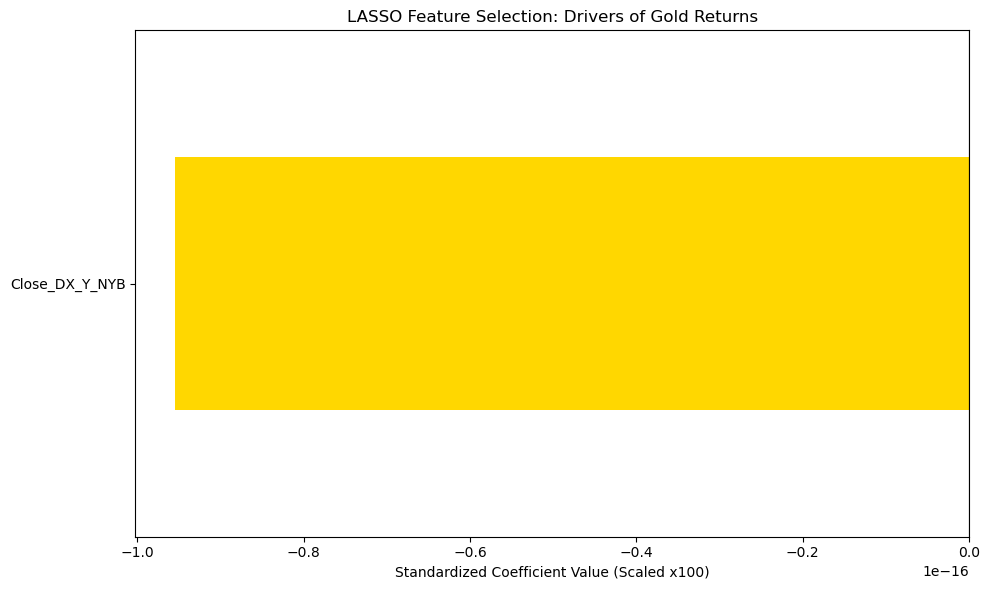

LASSO selected Variables for Member 4:
['Close_DX_Y_NYB']

Final Handoff for OLS: ['Close_DX_Y_NYB', 'wti_crude_oil_price', 'sp500_ret_lag', 'VIX_x_PostCovid']


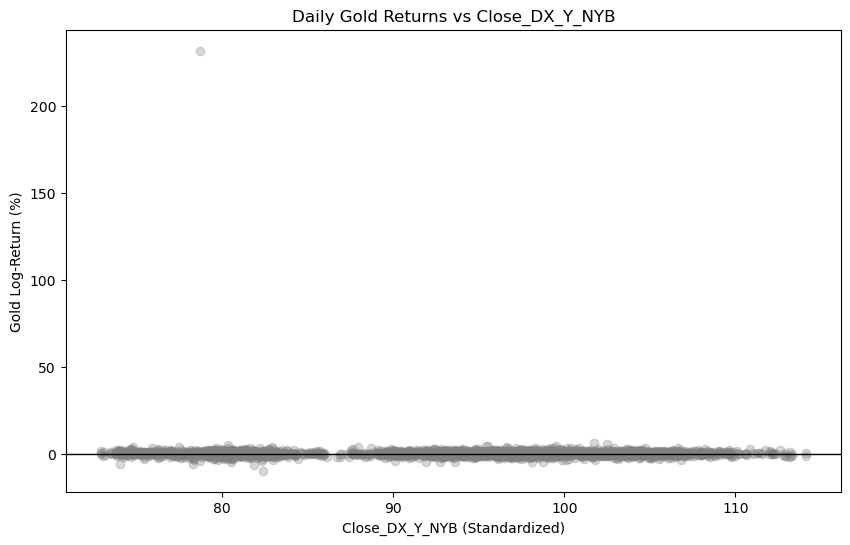

In [19]:
# final results
if not selected_features.empty:
    plt.figure(figsize=(10, 6))
    selected_features.plot(kind='barh', color='gold')
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.title("LASSO Feature Selection: Drivers of Gold Returns")
    plt.xlabel("Standardized Coefficient Value (Scaled x100)")
    plt.tight_layout()
    plt.show()

    handoff_list = selected_features.index.tolist()
    print("LASSO selected Variables for Member 4:")
    print(handoff_list)
else:
    # fallback: if LASSO zeros out, we pick the top 3 based on absolute correlation
    print("Warning: LASSO zeroed out all Coefficients.")
    top_correlated = correlations.abs().sort_values(ascending=False)
    handoff_list = top_correlated.index[1:4].tolist()
    print("Fallback: Recommended Variables for Member 4 based on Correlation:")
    print(handoff_list)

# defining the final research features for the OLS Model
# we use absolute values as strong negative correlation is equally important
abs_corr = train_df[features + ['gold_ret']].corr()['gold_ret'].abs().sort_values(ascending=False)
potential_drivers = abs_corr.drop('gold_ret')

# selecting the top variables and forcing the interaction Term into the handoff
handoff_vars = potential_drivers.head(3).index.tolist()
if 'VIX_x_PostCovid' not in handoff_vars:
    handoff_vars.append('VIX_x_PostCovid')

print(f"\nFinal Handoff for OLS: {handoff_vars}")

# visualizing why the LASSO struggled to select coefficients
# plotting Gold Returns against the top correlated variable
top_var = potential_drivers.index[0]
plt.figure(figsize=(10, 6))
plt.scatter(df[top_var], df['gold_ret'] * 100, alpha=0.3, color='gray')
plt.axhline(0, color='black', lw=1)
plt.title(f"Daily Gold Returns vs {top_var}")
plt.xlabel(f"{top_var} (Standardized)")
plt.ylabel("Gold Log-Return (%)")
plt.show()

## Section 3: Evaluating and Testing the "Broken Haven Hypothesis" Using OLS

Given the variables handed off from the previous section, we now will predict, first using post-covid variables and compare to actual post-covid gold returns.

Since LASSO selected no variables we will also provide another OLS test for the Broken Haven theory by running a more theoretical model on the entire dataset and the interaction term 'VIX_x_PostCovid' to identify if Gold's relationship with the market breaks down after our split point.

## Section 3.1.0: Old World vs New World Model

Using the Handoff Variables, we will train and evaluate a model using training data from before March 16th, 2022 (Old World) and predict and test the model on data after that point (New World)

In [22]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
#Using fallback handoff variables to train OLS model

#Remove interaction term for now
fallback_vars = [v for v in handoff_vars if v != 'VIX_x_PostCovid']

#Train Model using data from before 2022-03-16 (Old World) but on the handoff variables
X_train_ols = sm.add_constant(train_df[fallback_vars])
y_train_ols = train_df['gold_ret']
    # cov_type = "HC3" to account to heteroscedasticity
old_world_model = sm.OLS(y_train_ols, X_train_ols).fit(cov_type='HC3')

# Predict the "New World" (Post-March 2022)
X_test_ols = sm.add_constant(test_df[fallback_vars])
test_df['pred_gold_ret'] = old_world_model.predict(X_test_ols)

# Comparing Model Performances for Old vs New World data
train_rmse = np.sqrt(mean_squared_error(train_df['gold_ret'], old_world_model.predict(X_train_ols))) * 100
test_rmse = np.sqrt(mean_squared_error(test_df['gold_ret'], test_df['pred_gold_ret'])) * 100

print(f"Old World Training RMSE: {train_rmse:.6f}%")
print(f"New World Prediction RMSE: {test_rmse:.6f}%")
print(f"Old World Gold Return Standard Deviation: {train_df['gold_ret'].std()*100:.6f}%")
print(f"New Wolrd Gold Return Standard Deviation: {test_df['gold_ret'].std()*100:.6f}%")

print("\n--- OLS Regression Summary: The 'Old World' Rules ---")
print(old_world_model.summary())


Old World Training RMSE: 4.362609%
New World Prediction RMSE: 0.958916%
Old World Gold Return Standard Deviation: 4.364843%
New Wolrd Gold Return Standard Deviation: 0.956511%

--- OLS Regression Summary: The 'Old World' Rules ---
                            OLS Regression Results                            
Dep. Variable:               gold_ret   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8641
Date:                Sat, 11 Apr 2026   Prob (F-statistic):              0.459
Time:                        02:14:08   Log-Likelihood:                 5101.8
No. Observations:                2978   AIC:                        -1.020e+04
Df Residuals:                    2974   BIC:                        -1.017e+04
Df Model:                           3                                         
Covariance Type:                  HC3                     

### Section 3.1.1: Analysis of result (Old vs New World Model)

Although the RMSE decreased quite drastically (4.35% to 0.96%), looking at the summary statistics associated with model we see an R-Squared score of close to 0 as well as a prob(F-stat) of 0.459. We also see that the Standard Deviations so Gold Returns for the old and new world are almost exactly the RMSEs implying further that most of the variation in Gold Returns can be explained by random noise.

The mains takeaways from these findings are 1) Gold returns in the New World experience less volatility and 2) Gold Prices following a Random Walk seems like a reasonable scenario at least for the variables we've analyzed.

 ## Section 3.2.0: Interaction Analysis

Since our Old World vs New World has close to zero explanatory power, we will use an interaction between our cutoff date and the VIX closing price with our entire dataset to attempt to find validity in the Broken Haven hypothesis.


In [25]:
#include interaction terms into the handoff variable list
int_vars = handoff_vars + ['Close_VIX', 'is_PostCovid']

#No longer splitting into training and testing data
X_int = sm.add_constant(df[int_vars])
y_int = df['gold_ret']

interaction_model = sm.OLS(y_int, X_int).fit(cov_type='HC3')

print("\n--- Phase 2: Full Dataset Interaction Model Results ---")
print(interaction_model.summary())


--- Phase 2: Full Dataset Interaction Model Results ---
                            OLS Regression Results                            
Dep. Variable:               gold_ret   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                     1.573
Date:                Sat, 11 Apr 2026   Prob (F-statistic):              0.151
Time:                        02:14:08   Log-Likelihood:                 7153.4
No. Observations:                3889   AIC:                        -1.429e+04
Df Residuals:                    3882   BIC:                        -1.425e+04
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

### xSection 3.2.1: Analysis of Results (Interaction Model)

Once again we find that the model fits our data quite poorly with a R-Squared close to 0 and a low F-stat. We do see that post-covid "flips" the sign of the relationship between VIX closing price relative to the old world correlation however, neither effects are significant.


## Section 3.3: Analysis of Weekly Results

Overall, we see that for our linear models, moving to a weekly frequency yields more or less similar results to our daily model. The Weekly OLS and Lasso Variable Selection both produced R-Squared values close to 0, with p-values for major macro-drivers remaining insignificant. This suggests that a linear framework still perceives weekly gold returns as mostly random noise, failing to identify the underlying factors.

In [28]:
	
# Use the Fallback Variables (Top 3 Correlations) + Interaction Term
# We use fallback because LASSO shrunk every variable
fallback_vars_w = [v for v in handoff_vars_2010 if v != 'VIX_x_PostCovid']
X_ols_w = sm.add_constant(df_weekly[fallback_vars_w + ['Close_VIX', 'is_PostCovid']])

# Add the Interaction Term
df_weekly['VIX_x_PostCovid'] = df_weekly['Close_VIX'] * df_weekly['is_PostCovid']
X_ols_w = sm.add_constant(df_weekly[fallback_vars_w + ['Close_VIX', 'is_PostCovid', 'VIX_x_PostCovid']])

y_ols_w = df_weekly['gold_ret']

# 3. Fit the model
weekly_interaction_model = sm.OLS(y_ols_w, X_ols_w).fit(cov_type='HC3')

print("\n--- Phase 3: Weekly Interaction Model Results ---")
print(weekly_interaction_model.summary())

NameError: name 'handoff_vars_2010' is not defined

# Section 4: Testing a Non-linear Machine Learning Model (XGBoost)

Since our linear models seem to exhibit very little explanatory power, perhaps non-linear models can perform better. Existing research has shown that XGBoost has shown high accuracy and promise for predicting fluctuations in gold prices (Cohen & Aiche, 2023).

Extreme Gradient Boosting (XGBoost) models are Machine Learning algorithms that utilize decision trees, similar to random forest models. It differs in that the "branches" are built sequentially rather than simultaneously which means it can build on or "boost" previous iterations of the models leading to higher accuracy.

## Section 4.1.0: XGBoost Model using Daily Data

In [33]:
import sys
!{sys.executable} -m pip install xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Training: Using the training data already created in Section 2
# We use max_depth=3 to keep it simple and prevent overfitting on daily noise
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict the 'New World' (Post-March 2022)
# Re-using the 'features' list and 'scaler' from Section 2
X_test = test_df[features]
X_test_scaled = scaler.transform(X_test)
test_df['pred_gold_ret_xgb'] = xgb_model.predict(X_test_scaled)

# Calculate Errors
# CRITICAL: We must scale y_test by 100 to match y_train in Section 2
y_test_scaled = test_df['gold_ret'] * 100
train_preds_xgb = xgb_model.predict(X_train_scaled)

train_xgrmse = np.sqrt(mean_squared_error(y_train, train_preds_xgb))
test_xgrmse = np.sqrt(mean_squared_error(y_test_scaled, test_df['pred_gold_ret_xgb']))

# Market Volatility for Comparison (Standard Deviation of weekly returns)
vol_train = y_train.std()
vol_test = y_test_scaled.std()

print(f"XGBoost Training RMSE: {train_xgrmse:.6f}% (Market Vol: {vol_train:.2f}%)")
print(f"XGBoost Testing RMSE: {test_xgrmse:.6f}% (Market Vol: {vol_test:.2f}%)")

print(f"OLS Training RMSE: {train_rmse:.6f}%")
print(f"OLS RMSE: {test_rmse:.6f}%")

# Feature Importance (The "Econometrician" Insight)
# This shows what the AI thought was important BEFORE the haven broke
importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)
print("\nXGBoost Feature Importance (based on pre-covid training data):")
print(importance)

XGBoost Training RMSE: 4.761354% (Market Vol: 4.36%)
XGBoost Testing RMSE: 2.153756% (Market Vol: 0.96%)
OLS Training RMSE: 4.362609%
OLS RMSE: 0.958916%

XGBoost Feature Importance (based on pre-covid training data):
sp500_ret_lag          0.532189
gold_vol_lag           0.348961
Close_DX_Y_NYB         0.080306
wti_crude_oil_price    0.021494
interest_rate          0.006170
Close_VIX_lag          0.003152
sp500_ret              0.002287
Close_VIX              0.002252
gold_ret_lag           0.001866
expected_inflation     0.001322
dtype: float32


In [34]:
from sklearn.metrics import r2_score

#Calculate R-Squared
r2_train = r2_score(y_train, train_preds_xgb)
r2_test = r2_score(y_test_scaled, test_df['pred_gold_ret_xgb'])
print(f"Daily XGBoost R-Squared (Train): {r2_train:.4f}")
print(f"Daily XGBoost R-Squared (Test):  {r2_test:.4f}")

Daily XGBoost R-Squared (Train): -0.1903
Daily XGBoost R-Squared (Test):  -4.0756


## Section 4.1.1: Analysis of Daily Results

Using a more sophisticated algorthm like XGBoost, we're able to retrieve variables the algorithm deemed most important for predicting gold returns. 53% of the model's predictive logic can be represented by the lagged return of the S&P 500 which is consistent with findings from Cohen and Aiche (2023) and 35% was driven by the rolling standard deviation of gold returns over the past five trading days.

An interesting observation with the XGBoost model however, is that although the training RMSE follows closely the volatility of gold returns like the OLS model, the testing RMSE is actually higher than the market volatility. This implies that post March 2022, our model actual performs worse than random noise signaling a potential shift in the behaviour of gold returns.

Overall, at the daily level, even XGBoost models still exhibit negative R-Squared values implying low explanatory power which is most likely still dominated by random noise.

## Section 4.2.0: XGBoost Model using Weekly Data

In [37]:
#XGBoost Model
features_w = ['interest_rate', 'expected_inflation', 'wti_crude_oil_price',
              'sp500_ret', 'sp500_ret_lag', 'Close_VIX', 'Close_DX_Y_NYB',
              'gold_ret_lag', 'gold_vol_weekly', 'Close_VIX_lag']

# Split the Weekly Data (Pre/Post March 2022)
train_w = df_weekly[df_weekly.index < '2022-03-16'].copy()
test_w = df_weekly[df_weekly.index >= '2022-03-16'].copy()

# Prepare X and y (Scaling returns by 100 for sensitivity)
X_train_w = train_w[features_w]
y_train_w = train_w['gold_ret'] * 100

X_test_w = test_w[features_w]
y_test_w = test_w['gold_ret'] * 100

# Standardize Weekly Features
scaler_w = StandardScaler()
X_train_scaled_w = scaler_w.fit_transform(X_train_w)
X_test_scaled_w = scaler_w.transform(X_test_w)

# Train XGBoost
# We keep max_depth=3 to prevent the model from "hallucinating" patterns in the smaller weekly sample
xgb_weekly = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
xgb_weekly.fit(X_train_scaled_w, y_train_w)

# Predict and Evaluate
train_preds_w = xgb_weekly.predict(X_train_scaled_w)
test_preds_w = xgb_weekly.predict(X_test_scaled_w)

train_xgrmse_w = np.sqrt(mean_squared_error(y_train_w, train_preds_w))
test_xgrmse_w = np.sqrt(mean_squared_error(y_test_w, test_preds_w))

# Market Volatility for Comparison (Standard Deviation of weekly returns)
vol_train_w = y_train_w.std()
vol_test_w = y_test_w.std()

print(f"Weekly XGBoost Training RMSE: {train_xgrmse_w:.6f}% (Market Vol: {vol_train_w:.2f}%)")
print(f"Weekly XGBoost Testing RMSE:  {test_xgrmse_w:.6f}% (Market Vol: {vol_test_w:.2f}%)")

# Feature Importance
importance_w = pd.Series(xgb_weekly.feature_importances_, index=features_w).sort_values(ascending=False)
print("\nWeekly XGBoost Feature Importance:")
print(importance_w)

Weekly XGBoost Training RMSE: 1.985131% (Market Vol: 9.74%)
Weekly XGBoost Testing RMSE:  2.089248% (Market Vol: 2.08%)

Weekly XGBoost Feature Importance:
wti_crude_oil_price    0.575412
gold_vol_weekly        0.373660
Close_VIX_lag          0.008188
expected_inflation     0.007913
interest_rate          0.006739
sp500_ret              0.006731
Close_DX_Y_NYB         0.006534
sp500_ret_lag          0.005709
Close_VIX              0.005569
gold_ret_lag           0.003546
dtype: float32


In [38]:
from sklearn.metrics import r2_score

#Calculate R-Squared
r2_train_w = r2_score(y_train_w, train_preds_w)
r2_test_w = r2_score(y_test_w, test_preds_w)


print(f"Weekly XGBoost R-Squared (Train): {r2_train_w:.4f}")
print(f"Weekly XGBoost R-Squared (Test):  {r2_test_w:.4f}")

Weekly XGBoost R-Squared (Train): 0.9584
Weekly XGBoost R-Squared (Test):  -0.0137


## Section 4.2.1: Analysis of Weekly XGBoost Results

Our XGBoost model, when trained on weekly data, yields a breakthrough. By accounting for non-linear interactions, it achieves a Training R-Squared of 0.96 and a Training RMSE well below market volatility. The OLS vs. XGBoost results is a key finding: it proves that while the "Old World" rules existed, they were non-linear, requiring more sophisticated modeling to uncover.

In this weekly version, our driving variables have also shifted. Crude oil prices emerged as the primary driver (57% of importance), followed by gold return volatility from the previous week. This suggests that before 2022, gold traded less as a "financial" asset and more as a "geopolitical/energy" proxy.

Most importantly, both the R-squared and RMSE values worsen significantly once the model is used to predict "New World" era gold returns (Test R-Squared: -0.0137). This is the strong evidence for the "Broken Haven" hypothesis. The failure of even a high-performing XGBoost model to generalize to the post-March 2022 period confirms that the old rules have been replaced by a new, unobserved factors.


# **5. DATA VISUALIZATION**

This notebook focuses on exploratory data analysis (EDA) and visualization for the Broken Haven project.

## Section：5.1 Load and Inspect Data

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Data Check：
The cleaned dataset was loaded and sorted by date before visualization.

In [44]:
df = pd.read_csv("final_model_data.csv")
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

print("Date range:", df["DATE"].min(), "to", df["DATE"].max())
print("Number of observations:", len(df))

Date range: 2010-10-12 00:00:00 to 2025-09-09 00:00:00
Number of observations: 3889


In [45]:
df["Period"] = np.where(df["is_PostCovid"] == 1, "Post-COVID", "Pre-2022")
df[["DATE", "is_PostCovid", "Period"]].head()

,DATE,is_PostCovid,Period
0,2010-10-12,0,Pre-2022
1,2010-10-13,0,Pre-2022
2,2010-10-14,0,Pre-2022
3,2010-10-15,0,Pre-2022
4,2010-10-18,0,Pre-2022


## Section：5.2 Time-Series Visualizations

The modelling file defines the post-COVID period using the dummy variable `is_PostCovid`, which equals 1 from January 1, 2022 onward.

This section first creates readable period labels and then visualizes key variables over time.

In [48]:
df["Period"] = np.where(df["is_PostCovid"] == 1, "Post-COVID", "Pre-2022")
df[["DATE", "is_PostCovid", "Period"]].head()

,DATE,is_PostCovid,Period
0,2010-10-12,0,Pre-2022
1,2010-10-13,0,Pre-2022
2,2010-10-14,0,Pre-2022
3,2010-10-15,0,Pre-2022
4,2010-10-18,0,Pre-2022


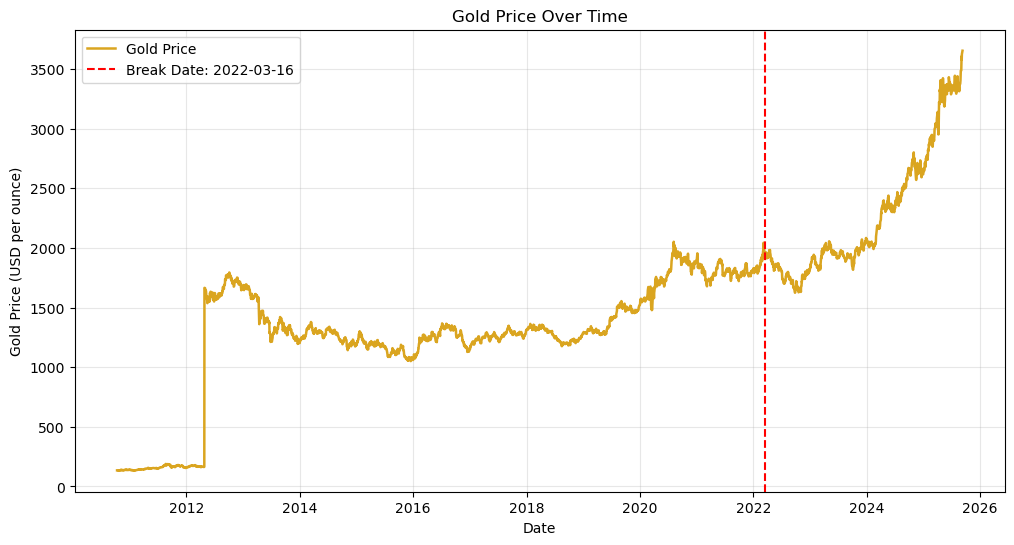

In [49]:
split_date = pd.Timestamp("2022-03-16")

plt.figure(figsize=(12,6))
plt.plot(df["DATE"], df["Close_MGC_F"], color="goldenrod", linewidth=1.8, label="Gold Price")
plt.axvline(split_date, color="red", linestyle="--", linewidth=1.5, label="Break Date: 2022-03-16")

plt.title("Gold Price Over Time")
plt.xlabel("Date")
plt.ylabel("Gold Price (USD per ounce)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation

This figure shows how gold prices moved over time, with March 16, 2022 marked as the structural break date. Gold prices continue to fluctuate before and after the break, which suggests that market conditions may have changed across the two periods. This provides background for testing whether gold behaved differently after the break.

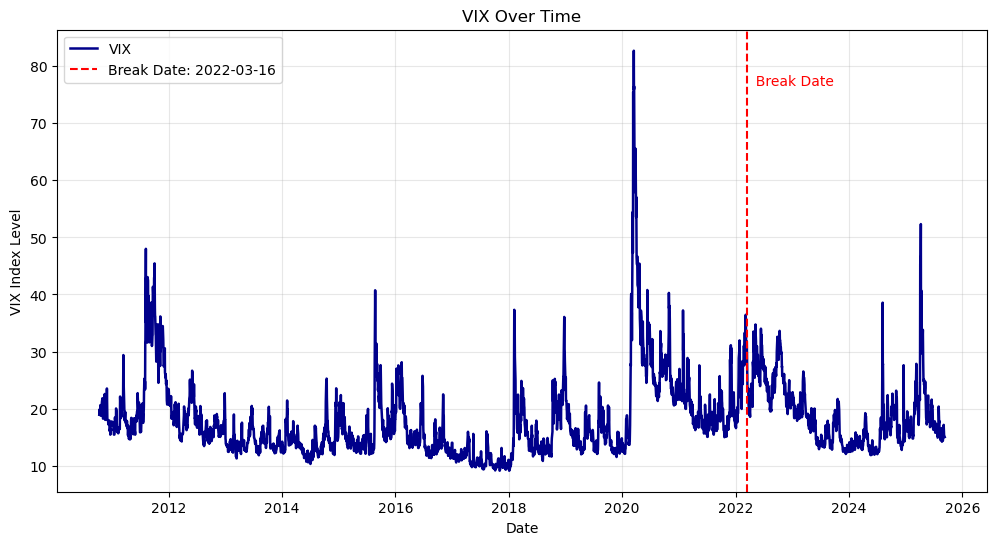

In [51]:
split_date = pd.Timestamp("2022-03-16")

plt.figure(figsize=(12,6))
plt.plot(df["DATE"], df["Close_VIX"], color="darkblue", linewidth=1.8, label="VIX")
plt.axvline(split_date, color="red", linestyle="--", linewidth=1.5, label="Break Date: 2022-03-16")

plt.title("VIX Over Time")
plt.xlabel("Date")
plt.ylabel("VIX Index Level")
plt.legend()
plt.grid(alpha=0.3)

y_max = df["Close_VIX"].max()
plt.text(split_date, y_max * 0.95, "  Break Date", color="red", va="top")

plt.show()

The VIX measures market stress and uncertainty. Since the project tests whether gold retained its safe-haven role, this is one of the most important explanatory variables.

## Section：5.3 Connecting Gold Prices and Market Stress

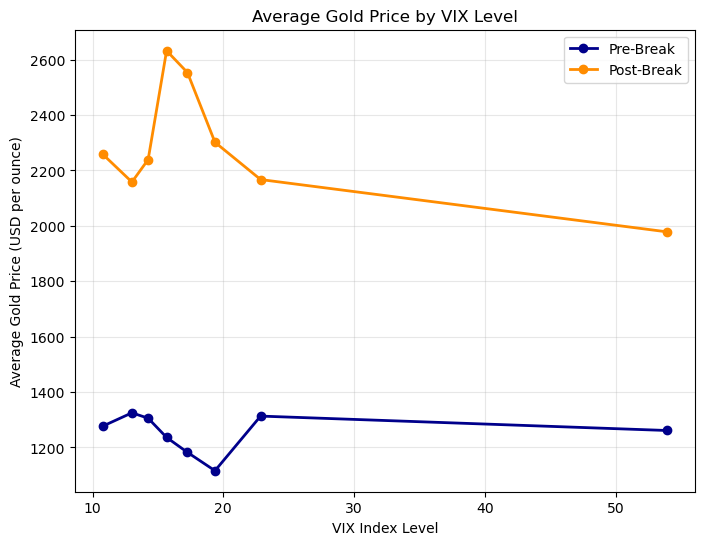

In [54]:
split_date = pd.Timestamp("2022-03-16")
df["Period"] = np.where(df["DATE"] >= split_date, "Post-Break", "Pre-Break")

plot_df = df[["Close_VIX", "Close_MGC_F", "Period"]].dropna().copy()
plot_df["VIX_bin"] = pd.qcut(plot_df["Close_VIX"], q=8, duplicates="drop")

grouped = plot_df.groupby(["Period", "VIX_bin"], observed=False)["Close_MGC_F"].mean().reset_index()
grouped["VIX_mid"] = grouped["VIX_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(8,6))

for period, color in [("Pre-Break", "darkblue"), ("Post-Break", "darkorange")]:
    subset = grouped[grouped["Period"] == period]
    plt.plot(
        subset["VIX_mid"],
        subset["Close_MGC_F"],
        marker="o",
        linewidth=2,
        color=color,
        label=period
    )

plt.title("Average Gold Price by VIX Level")
plt.xlabel("VIX Index Level")
plt.ylabel("Average Gold Price (USD per ounce)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation

After examining gold prices and VIX separately over time, the next step is to look at how they are related. This figure compares average gold prices across different levels of market stress before and after the structural break on March 16, 2022.

If gold responded to market stress in the same way across both periods, the two lines would show a similar pattern. If the pattern differs after the break, this suggests that the relationship between gold and market stress may have become less stable.

## Section 6 Model Results Summary

### 6.1 Lasso Feature Selection Summary

The modelling stage first applied Lasso regression to the candidate predictors in order to reduce multicollinearity and identify the most relevant variables for explaining daily gold returns.

However, under the current specification, the Lasso penalty shrank all coefficients to zero. This suggests that none of the candidate variables showed strong enough predictive power to remain in the model after regularization.

Because of this result, the analysis proceeded with a fallback variable set based on correlation patterns and modelling judgment. The variables passed to the OLS stage were:

- `Close_DX_Y_NYB`
- `wti_crude_oil_price`
- `sp500_ret_lag`
- `VIX_x_PostCovid`

This outcome suggests that daily gold returns may be difficult to predict using these macro-financial variables alone, possibly because gold returns are dominated by short-term noise.

### 6.2 OLS Regression Results

The final interaction model was estimated using OLS with HC3 robust standard errors. The model included the following predictors:

- `Close_DX_Y_NYB`
- `wti_crude_oil_price`
- `sp500_ret_lag`
- `Close_VIX`
- `is_PostCovid`
- `VIX_x_PostCovid`

The main purpose of this specification was to test whether the relationship between market stress and gold returns changed in the post-COVID period.

The regression results show that the interaction term `VIX_x_PostCovid` is not statistically significant. In addition, `Close_VIX` and `is_PostCovid` are also not statistically significant. This means that the model does not provide strong evidence that the effect of VIX on gold returns changed after the post-COVID break.

Among the included variables, `Close_DX_Y_NYB` is the closest to significance, but it still does not reach the 5% significance level. Overall, the model has very low explanatory power, which indicates that the selected predictors explain only a very small share of the variation in daily gold returns.

Therefore, while the descriptive plots may suggest some visual differences across periods, the formal OLS results do not strongly support the Broken Haven hypothesis.
| Variable | Coefficient | p-value | Interpretation |
|----------|-------------|---------|----------------|
| Close_DX_Y_NYB | -0.0001 | 0.063 | Negative but not significant at the 5% level |
| wti_crude_oil_price | -9.458e-07 | 0.979 | No significant relationship |
| sp500_ret_lag | 0.0528 | 0.196 | No significant relationship |
| Close_VIX | 6.826e-06 | 0.892 | No significant relationship |
| is_PostCovid | 0.0021 | 0.174 | No significant shift in average gold returns |
| VIX_x_PostCovid | -2.582e-05 | 0.795 | No significant post-COVID change in the VIX effect |

### 6.3 XGBoost Results

In addition to the OLS model, we applied XGBoost as a nonlinear machine learning benchmark to examine whether a more flexible specification could better capture the relationship between gold returns and macro-financial variables.

Using the same structural break date of March 16, 2022, the XGBoost model was trained on the pre-break sample and then evaluated on the post-break period. This approach allows us to test whether a model that performs well in the “old world” can still generalize after the suspected shift in market structure.

At the daily level, the XGBoost model does not perform well out of sample. The training RMSE is 4.761354%, while the testing RMSE increases to 2.153756%, compared with post-break market volatility of about 0.96%. In addition, the daily XGBoost model produces negative R-squared values in both the training and testing samples, which suggests that daily gold returns remain highly noisy and difficult to predict.

At the weekly level, however, the XGBoost model performs much better in-sample. It achieves a training RMSE of 1.985131% and a training R-squared of 0.9584, suggesting that nonlinear relationships may have been important in the pre-break period. The most important predictors in the weekly model are `wti_crude_oil_price` and `gold_vol_weekly`, which together account for most of the model’s predictive importance.

However, the weekly model also weakens noticeably in the post-break period. The testing RMSE rises to 2.089248%, and the testing R-squared falls to -0.0137. This suggests that even a stronger nonlinear model struggles to generalize after March 16, 2022.

Overall, the XGBoost results complement the OLS findings. They suggest that pre-break gold-return dynamics may contain nonlinear structure, but the predictive relationship becomes less stable in the post-break period. This provides additional support for the idea that the historical “safe-haven” relationship became harder to capture after the structural break.

| Model | Train RMSE | Test RMSE | Train R² | Test R² | Main Takeaway |
|------|------------|-----------|----------|---------|---------------|
| Daily XGBoost | 4.761354% | 2.153756% | -0.1903 | -4.0756 | Very weak predictive power; daily returns remain noisy |
| Weekly XGBoost | 1.985131% | 2.089248% | 0.9584 | -0.0137 | Strong in-sample fit, but weak post-break generalization |

# **7. Conclusion**

**This project set out to answer one central question: has gold's role as a safe-haven asset broken down since the COVID-19 pandemic?** Using LASSO variable selection, OLS regression, and XGBoost — at both daily and weekly frequencies — we tested whether the relationship between gold and market stress measurably shifted after March 2022. **The short answer is: the evidence points toward yes, but it's more subtle than a clean structural break.**

The linear models were largely unable to explain gold's movements using macro-financial variables alone, suggesting that on a day-to-day basis, gold returns behave closer to random noise than to a predictable, fundamentals-driven asset. **The most compelling evidence came from XGBoost at the weekly level — before 2022, the model found real, learnable patterns, with gold behaving primarily as a geopolitical and commodity proxy tracking crude oil. After 2022, those patterns vanished entirely.** A model that genuinely understood the Old World had nothing useful to say about the New World, which is difficult to attribute to chance alone.

**One limitation worth acknowledging is that every variable in this study measures what markets are doing — prices, returns, volatility — but none captures what investors are actually thinking.** Sentiment, narrative, and fear are arguably important gold drivers. **Future work could directly address this by augmenting the model with real-time sentiment variables — such as news sentiment indices or search trend data — to test whether the Broken Haven effect is better explained by a shift in how investors *perceive* gold than by any change in the underlying macro environment.**

# **6. SOURCES** 

#### Bampinas, G., & Panagiotidis, T. (2015). Are gold and silver a hedge against inflation? A two century perspective. International Review of Financial Analysis, 41, 267–276. https://doi.org/10.1016/j.irfa.2015.02.007

#### Board of Governors of the Federal Reserve System (US). (1980, November 3). M2. FRED, Federal Reserve Bank of St. Louis. https://fred.stlouisfed.org/series/WM2NS

#### Cohen, Gil & Aiche, Avishay, 2023. "Forecasting gold price using machine learning methodologies," Chaos, Solitons & Fractals, Elsevier, vol. 175(P2).

   - Uses XGBoost and GBTR models to predict gold price fluctuates. Yielded promising accuracy with XGBoost when combine with lagged market variables. Did not account for Broken Haven as paper would have only had access to Old World Data

#### Faraj, H., McMillan, D., & Al-Sabah, M. (2025). The diminishing lustre: Gold’s market volatility and the fading safe haven effect. Global Finance Journal, 101145–101145. https://doi.org/10.1016/j.gfj.2025.101145

#### Federal Reserve Bank of Cleveland. (1982a, January 1). 10-Year Expected Inflation. FRED, Federal Reserve Bank of St. Louis. https://fred.stlouisfed.org/series/EXPINF10YR

#### Federal Reserve Bank of Cleveland. (1982b, January 1). 10-Year Real Interest Rate. FRED, Federal Reserve Bank of St. Louis. https://fred.stlouisfed.org/series/REAINTRATREARAT10Y

#### Federal Reserve Bank of St. Louis. (2025, April 16). Inflation, Consumer Prices for the United States. Stlouisfed.org. https://fred.stlouisfed.org/series/FPCPITOTLZGUSA

#### FRED. (2025). 10-Year Treasury Constant Maturity Rate. FRED, Federal Reserve Bank of St. Louis. https://fred.stlouisfed.org/series/DGS10

#### International Monetary Fund. (1980, January 1). Global price of WTI Crude. FRED, Federal Reserve Bank of St. Louis. https://fred.stlouisfed.org/series/POILWTIUSDM

#### Jaffer, Z. (2024, June 26). Gold vs. Bonds and Stocks: Why Some Investors Choose Gold. Rolling Stone. https://www.rollingstone.com/culture-council/articles/gold-vs-bonds-stocks-some-investors-choose-gold-1235046412/

#### JP Morgan. (2024, January 17). Will gold prices hit another all-time high? | J.P. Morgan Research. Www.jpmorgan.com. https://www.jpmorgan.com/insights/global-research/commodities/gold-prices

#### Li, Shumeng. (2023). The Impact of the Federal Reserve Raises the Interest Rates on the US Stock Market Index: The Dynamic Perspective. Advances in Economics, Management and Political Sciences. 61. 265-274. 10.54254/2754-1169/61/20231283. 

#### Shreyansh Dangi. (2025). Gold-Silver Price VS Geopolitical Risk (1985–2025). Kaggle.com. https://www.kaggle.com/datasets/shreyanshdangi/gold-silver-price-vs-geopolitical-risk-19852025/data

#### The Assay. (2020, March 26). COVID-19 and the Gold Price. The Assay. https://www.theassay.com/articles/covid-19-and-the-gold-price/

#### U.S. Bureau of Economic Analysis. (2025, April 30). Gross Domestic Product. Stlouisfed.org. https://fred.stlouisfed.org/series/GDP

#### World Gold Council. (2025a). Gold in the Global Economy: Market, mining and modernisation. World Gold Council. https://www.gold.org/about-gold/gold-global-economy

#### World Gold Council. (2025b, December 4). Gold Outlook 2026: Push ahead or pull back. World Gold Council. https://www.gold.org/goldhub/research/gold-outlook-2026

#### Yahoo Finance. (2026a). CBOE Volatility Index (^VIX) Historical Data - Yahoo Finance. Yahoo Finance. https://ca.finance.yahoo.com/quote/%5EVIX/history/?period1=662774400&period2=1775002325

#### Yahoo Finance. (2026b). S&P 500 (^GSPC) Historical Data - Yahoo Finance. Ca.finance.yahoo.com. https://ca.finance.yahoo.com/quote/%5EGSPC/history/

#### Yahoo Finance. (2026c). US Dollar Index (DX-Y.NYB) Historical Data - Yahoo Finance. Yahoo Finance. https://ca.finance.yahoo.com/quote/DX-Y.NYB/history/?period1=662774400&period2=1775010540

#### You, Wanhai & Chen, Jianyong & Xie, Haoqi & Ren, Yinghua, 2025. "Which uncertainty measure better predicts gold prices? New evidence from a CNN-LSTM approach," The North American Journal of Economics and Finance, Elsevier, vol. 76(C).

   - Uses CNN-LSTM neural network models to predict gold prices using economic policy uncertainty index and volatility indices which yieled better accuracy than other traditional LSTM and Vector Regression models. They however, only use data spannign 2018- September 2022 which may not fully embrace the long-run effects of the Broken Haven phenomenon
